In [9]:
import pandas as pd

df = pd.read_csv('cleaned_dataset.csv')

C:\Users\mihir\AppData\Local\Temp\ipykernel_33476\118581715.py:3: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cleaned_dataset.csv')


In [10]:
df.head()

,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,False,False,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,False,False,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,False,False,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,False,False,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,False,False,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [11]:
df.dtypes


asteroid_id                               int64
asteroid_name                            object
near_earth_object                        object
potentially_hazardous                    object
absolute_magnitude                      float64
diameter_km                             float64
surface_reflectivity                    float64
diameter_uncertainty_km                 float64
orbit_solution_id                        object
orbit_epoch                             float64
orbit_epoch_mjd                           int64
orbit_epoch_calendar                      int64
orbital_eccentricity                    float64
semi_major_axis_au                      float64
perihelion_distance_au                  float64
orbital_inclination_deg                 float64
longitude_ascending_node_deg            float64
argument_perihelion_deg                 float64
mean_anomaly_deg                        float64
aphelion_distance_au                    float64
mean_motion_deg_day                     

Outlier Counts in each columns: {'absolute_magnitude': 47423, 'aphelion_distance_au': 29934, 'argument_perihelion_deg': 0, 'diameter_km': 34281, 'diameter_uncertainty_km': 20600, 'earth_moid_au': 26543, 'earth_moid_ld': 41168, 'longitude_ascending_node_deg': 0, 'mean_anomaly_deg': 0, 'mean_motion_deg_day': 24106, 'orbit_epoch': 49138, 'orbit_epoch_calendar': 49138, 'orbit_epoch_mjd': 49138, 'orbit_fit_rms': 64788, 'orbital_eccentricity': 24800, 'orbital_inclination_deg': 30285, 'orbital_period_days': 22271, 'orbital_period_years': 22274, 'perihelion_distance_au': 29430, 'semi_major_axis_au': 24919, 'surface_reflectivity': 67372, 'time_perihelion_calendar': 36149, 'time_perihelion_passage': 35813, 'uncertainty_aphelion_distance': 207392, 'uncertainty_argument_perihelion': 198386, 'uncertainty_eccentricity': 217671, 'uncertainty_longitude_ascending_node': 155578, 'uncertainty_mean_anomaly': 201213, 'uncertainty_mean_motion': 205566, 'uncertainty_orbital_inclination': 180517, 'uncertainty

C:\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper 

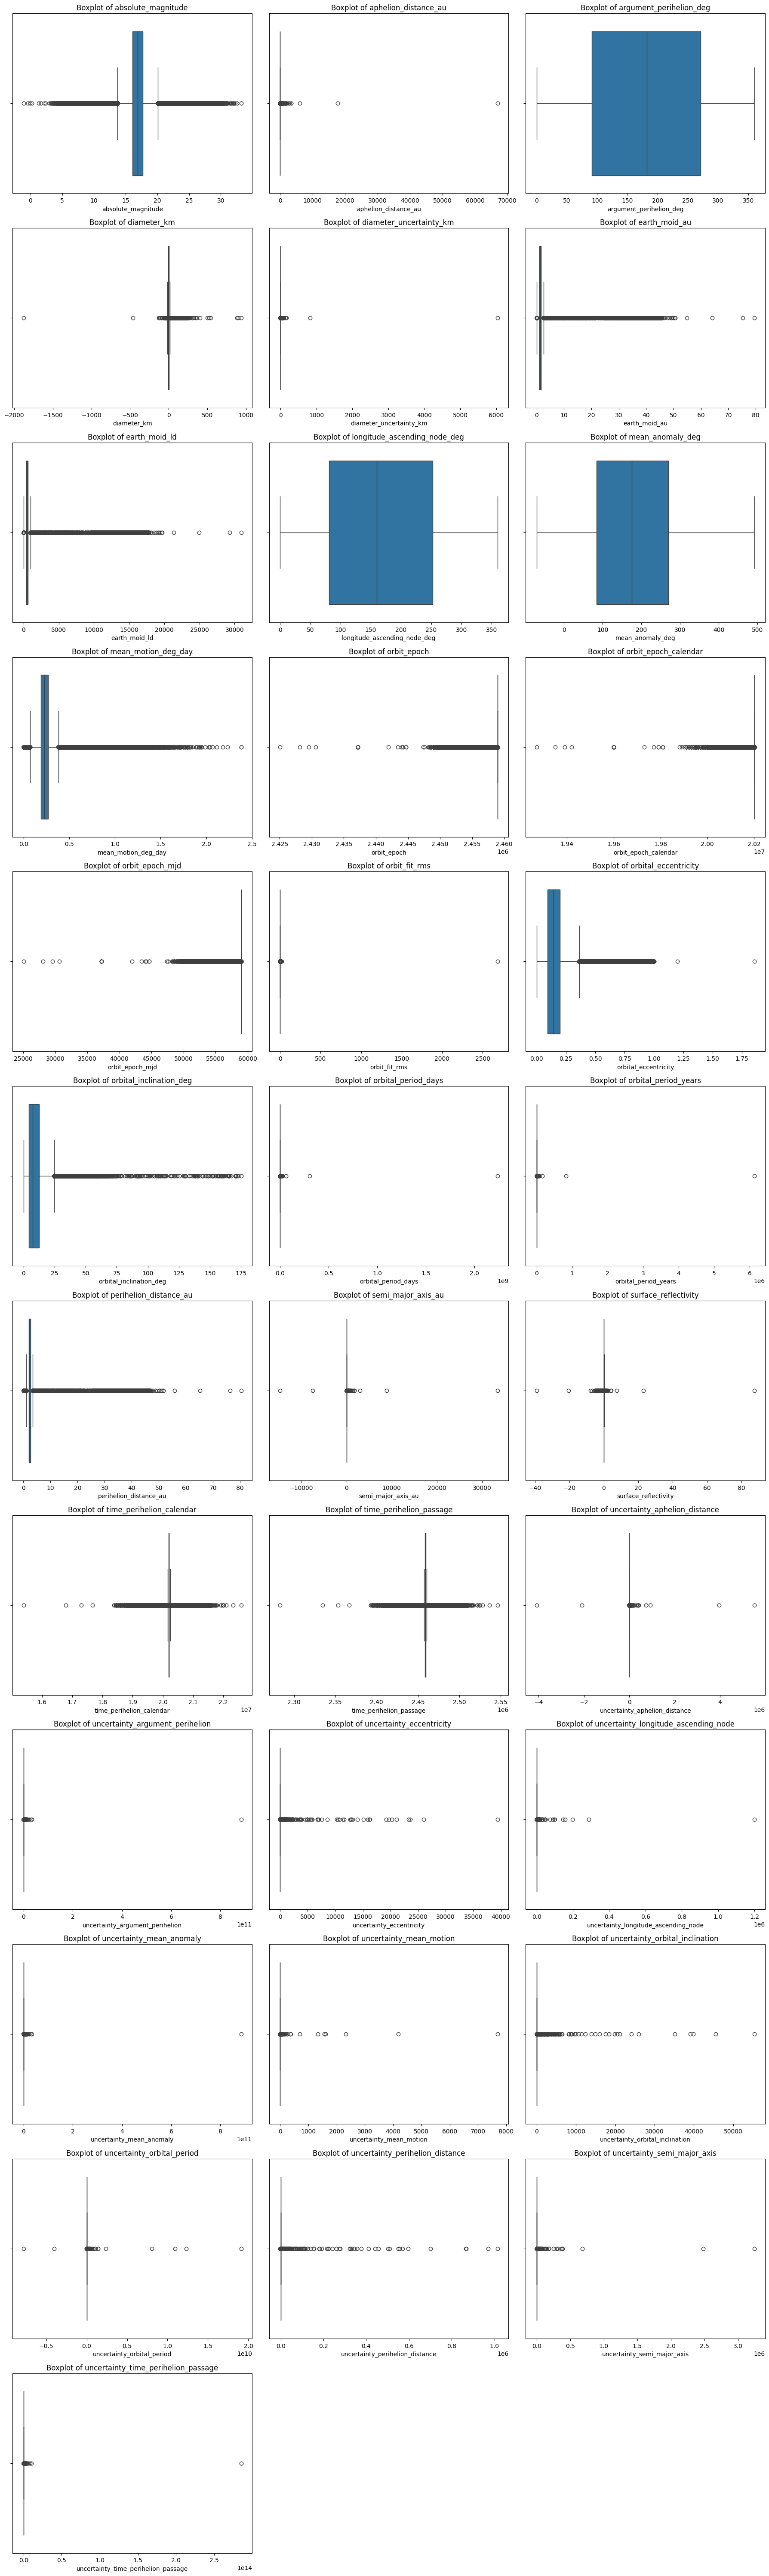

['asteroid_id', 'asteroid_name']

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Identify unique identifier columns (columns where all values are unique)
unique_id_columns = [col for col in df.columns if df[col].nunique() == len(df)]

# Remove unique identifier columns from numerical analysis
num_columns = df.select_dtypes(include=['float64', 'int64']).columns.difference(unique_id_columns)

# Function to detect outliers using the IQR method
def detect_outliers(df, columns):
    outlier_indices = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_indices[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    return outlier_indices

# Detect outliers in numerical columns
outlier_indices = detect_outliers(df, num_columns)

# Count the number of outliers per column
outlier_counts = {col: len(outlier_indices[col]) for col in num_columns}

# Convert to DataFrame for visualization
outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Column', 'Outlier Count'])

print("Outlier Counts in each columns:", outlier_counts)
# Visualizing outliers using boxplots
fig, axes = plt.subplots(nrows=len(num_columns)//3 + 1, ncols=3, figsize=(18, 5 * (len(num_columns)//3 + 1)))
axes = axes.flatten()

# Generate boxplots for each numerical column (excluding unique identifier columns)
for i, col in enumerate(num_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output unique identifier columns that were excluded
unique_id_columns


In [20]:
# Exclude non-numeric columns
excluded_columns = ['asteroid_id', 'asteroid_name', 'near_earth_object', 'potentially_hazardous',
                    'orbit_solution_id', 'asteroid_class']
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.difference(excluded_columns)


In [22]:
# Function to remove extreme outliers using IQR method (Mild Trimming)
def remove_outliers_iqr(df, columns):
    df_cleaned = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Remove extreme outliers
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

# Applying IQR filtering on selected columns
columns_to_filter = ['diameter_km', 'surface_reflectivity', 'orbital_period_days', 'orbital_period_years']
df_filtered = remove_outliers_iqr(df, columns_to_filter)


In [23]:
# Apply domain knowledge filtering
df_filtered = df_filtered[df_filtered['diameter_km'] > 0]  # Diameter should always be positive


In [24]:
df_filtered.head()

,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
253,2000254,254 Augusta,False,False,11.7,12.467000,0.170000,0.137000,JPL 32,2459000.5,...,0.000004,0.000040,0.000044,0.000021,6.240000e-09,1.150000e-09,0.000068,0.000005,MBA,0.40909
472,2000473,473 Nolli (1901 GC),False,False,11.7,12.394000,0.138000,0.138000,JPL 34,2459000.5,...,0.000005,0.000019,0.000029,0.000021,1.320000e-08,1.520000e-09,0.000092,0.000011,MBA,0.37280
718,2000719,719 Albert (1911 MT),True,False,15.4,7.581494,0.145937,-0.167142,JPL 214,2459000.5,...,0.000003,0.000017,0.000017,0.000003,3.910000e-09,3.310000e-10,0.000010,0.000002,AMO,0.39148
723,2000724,724 Hapag (1911 NC),False,False,13.8,9.492000,0.103000,0.198000,JPL 29,2459000.5,...,0.000005,0.000019,0.000021,0.000007,1.240000e-08,1.550000e-09,0.000026,0.000009,MBA,0.48206
727,2000728,728 Leonisis (1912 NU),False,False,12.9,5.887000,0.160000,0.481000,JPL 41,2459000.5,...,0.000003,0.000048,0.000052,0.000020,6.060000e-09,1.080000e-09,0.000069,0.000005,MBA,0.43402


C:\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


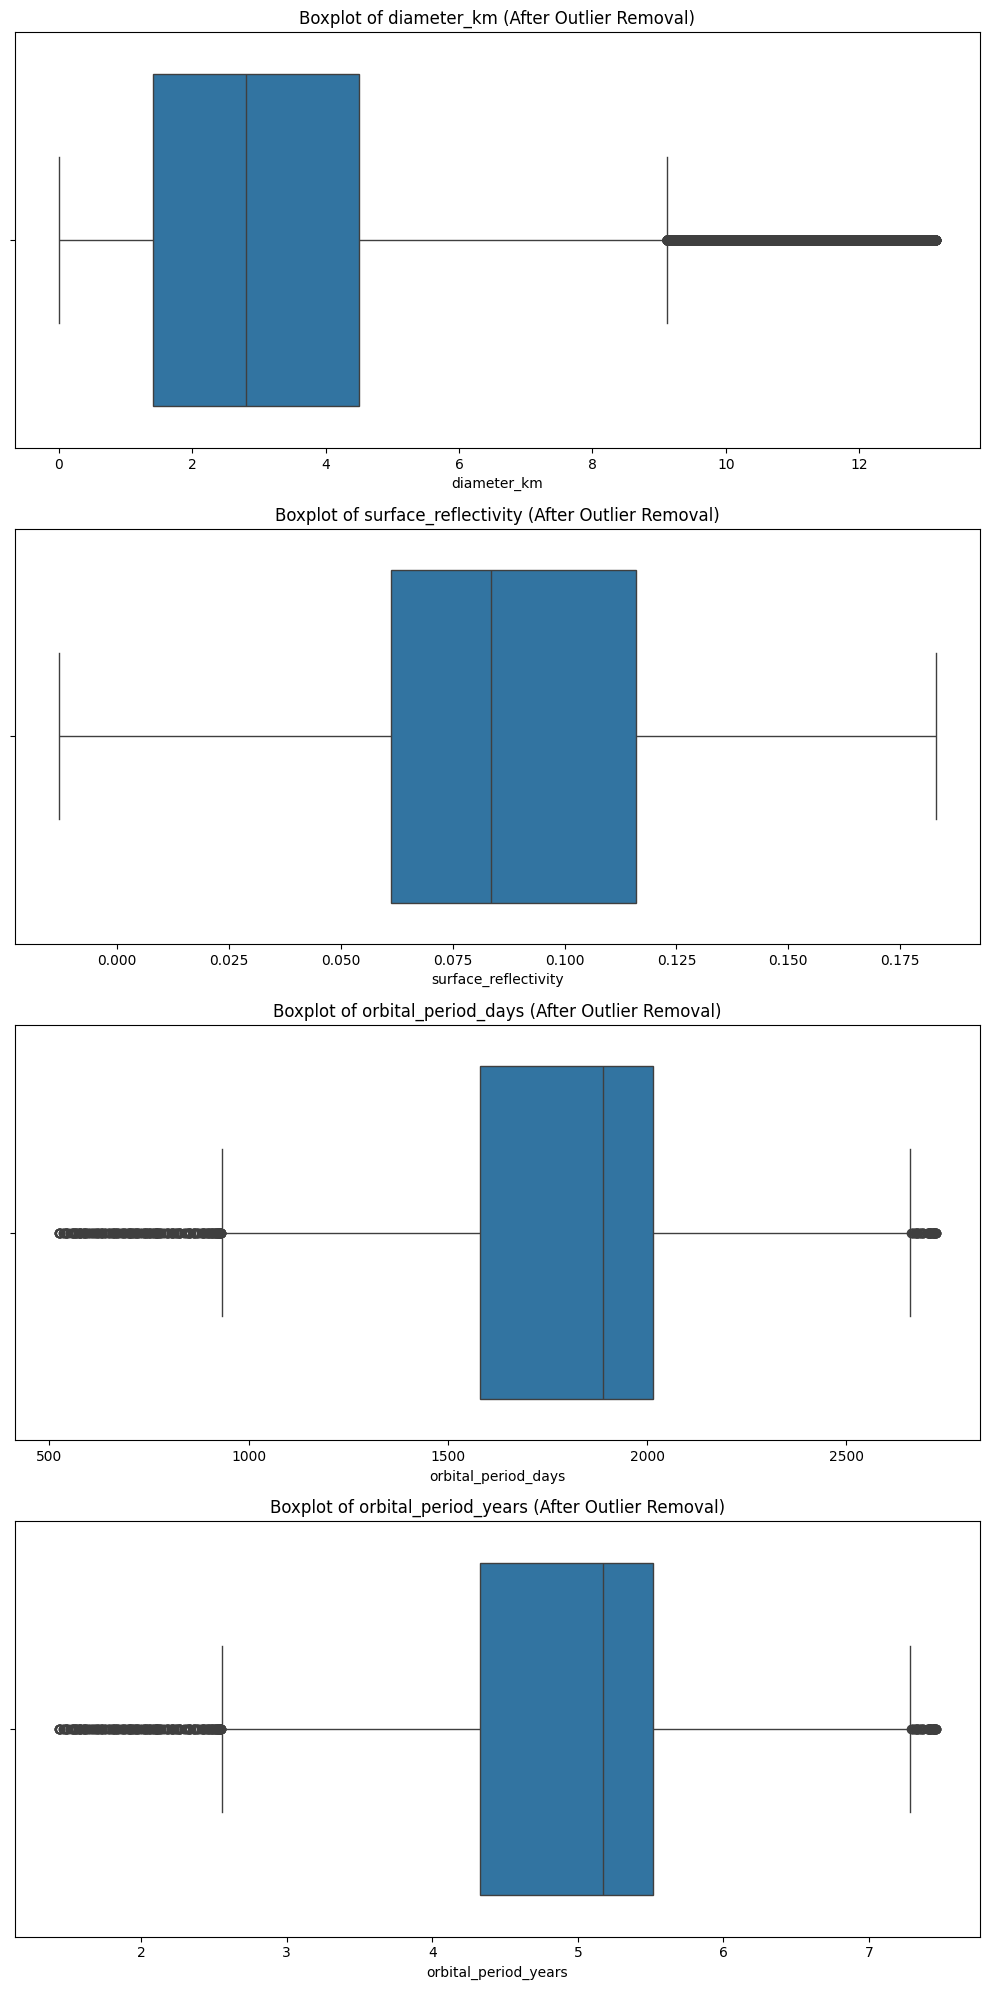

In [25]:
# Re-checking for outliers in the cleaned dataset

# Set up visualization for outlier detection after filtering
fig, axes = plt.subplots(nrows=len(columns_to_filter), ncols=1, figsize=(10, 5 * len(columns_to_filter)))

# Generate boxplots for each cleaned column
for i, col in enumerate(columns_to_filter):
    sns.boxplot(x=df_filtered[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} (After Outlier Removal)')

plt.tight_layout()
plt.show()


In [26]:
cleaned_outliers_file = "cleaned_dataset_no_outliers.csv"
df_filtered.to_csv(cleaned_outliers_file, index=False)

In [28]:
df_filtered.describe()

,asteroid_id,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_epoch,orbit_epoch_mjd,orbit_epoch_calendar,orbital_eccentricity,semi_major_axis_au,...,uncertainty_perihelion_distance,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,orbit_fit_rms
count,3.686960e+05,368696.000000,368696.000000,368696.000000,368696.000000,3.686960e+05,368696.000000,3.686960e+05,368696.000000,368696.000000,...,3.686960e+05,368696.000000,3.686960e+05,3.686960e+05,3.686960e+05,3.686960e+05,3.686960e+05,3.686960e+05,3.686960e+05,3.686960e+05
mean,2.857908e+06,15.938628,3.209794,0.090316,0.547723,2.458934e+06,58933.474998,2.019871e+07,0.145163,2.881193,...,7.003175e-01,0.510190,2.853572e+00,-2.413873e+03,4.368084e+03,7.622012e-01,5.522688e-02,1.489856e+06,7.572575e+02,5.689641e-01
std,3.865130e+06,0.798977,2.330173,0.036606,0.292285,5.038193e+02,503.819272,1.377499e+04,0.079393,0.286239,...,2.078636e+02,91.552001,3.291158e+02,1.796310e+05,7.674694e+04,4.222683e+01,3.952948e+00,7.906102e+07,3.357120e+04,7.442616e-02
min,2.000254e+06,11.000000,0.000006,-0.013075,-0.816008,2.437204e+06,37203.000000,1.960093e+07,0.000060,1.270946,...,-6.918937e+01,-0.403952,5.350000e-07,-8.113052e+06,2.100000e-07,-3.393711e+01,3.400000e-11,-1.466422e+09,-2.081571e+05,3.290000e-11
25%,2.146224e+06,15.500000,1.417552,0.061301,0.332888,2.459000e+06,59000.000000,2.020053e+07,0.085779,2.656382,...,1.380000e-07,0.000005,2.840000e-05,4.380000e-05,2.110000e-05,2.300000e-08,2.320000e-09,9.920000e-05,1.830000e-05,5.320300e-01
50%,2.300866e+06,16.100000,2.807000,0.083532,0.559928,2.459000e+06,59000.000000,2.020053e+07,0.135861,2.989913,...,1.900000e-07,0.000007,4.320000e-05,6.770000e-05,3.450000e-05,3.840000e-08,3.420000e-09,1.745000e-04,3.180000e-05,5.670800e-01
75%,2.519330e+06,16.500000,4.495000,0.116069,0.726932,2.459000e+06,59000.000000,2.020053e+07,0.193256,3.121028,...,2.900000e-07,0.000010,7.690000e-05,1.190700e-04,6.560000e-05,6.880000e-08,5.580000e-09,3.481700e-04,5.850000e-05,6.052200e-01
max,5.401706e+07,27.500000,13.151000,0.183048,7.172000,2.459000e+06,59000.000000,2.020053e+07,0.968396,3.818533,...,1.261300e+05,55330.000000,1.978800e+05,8.840000e+06,3.489900e+06,2.483100e+04,2.326700e+03,1.299281e+10,1.889600e+07,7.725100e+00
